In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/netflix_titles.csv')

### Dataset Overview

Let's take a look at the first few rows of the dataset and check its general information, including data types and non-null values.

### Exploratory Data Analysis (EDA)

Let's visualize various aspects of the dataset to uncover insights and patterns.

/tmp/ipykernel_10591/1334353661.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=df, palette='viridis')


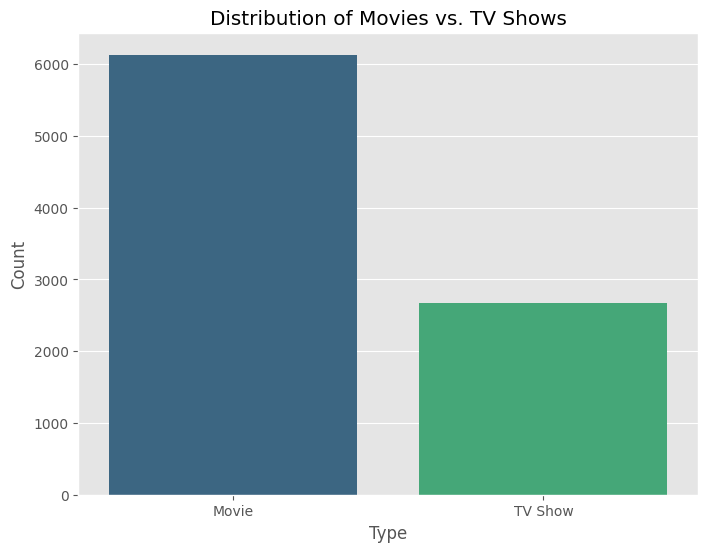

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot') # Set a nice plotting style

# Distribution of Content Types (Movies vs. TV Shows)
plt.figure(figsize=(8, 6))
sns.countplot(x='type', data=df, palette='viridis')
plt.title('Distribution of Movies vs. TV Shows')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

### Content Added Over Time

Let's see how the number of titles added to Netflix has changed over the years.

### Top Countries Producing Content

Let's identify which countries are contributing the most content to Netflix. Note that a single title can be associated with multiple countries.

/tmp/ipykernel_10591/548033.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.index, y=top_countries.values, palette='cubehelix')


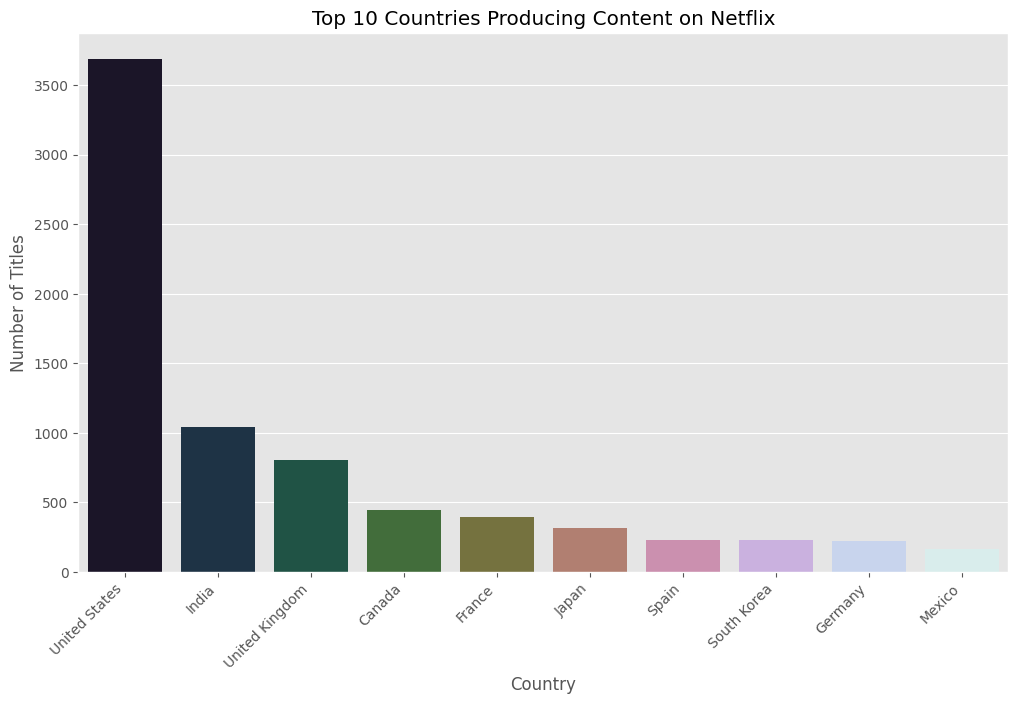

In [12]:
# Function to split and count occurrences of items in a column
def count_occurrences(df_col):
    # Drop 'Unknown' and split by comma
    split_items = df_col[df_col != 'Unknown'].str.split(', ')
    # Explode the list of lists into a series of individual items
    flat_list = [item for sublist in split_items.dropna() for item in sublist]
    return pd.Series(flat_list).value_counts()

# Top 10 Countries
top_countries = count_occurrences(df['country']).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_countries.index, y=top_countries.values, palette='cubehelix')
plt.title('Top 10 Countries Producing Content on Netflix')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.show()

### Content Ratings Distribution

Let's visualize the distribution of content ratings.

/tmp/ipykernel_10591/1297356506.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, order=df['rating'].value_counts().index, palette='viridis')


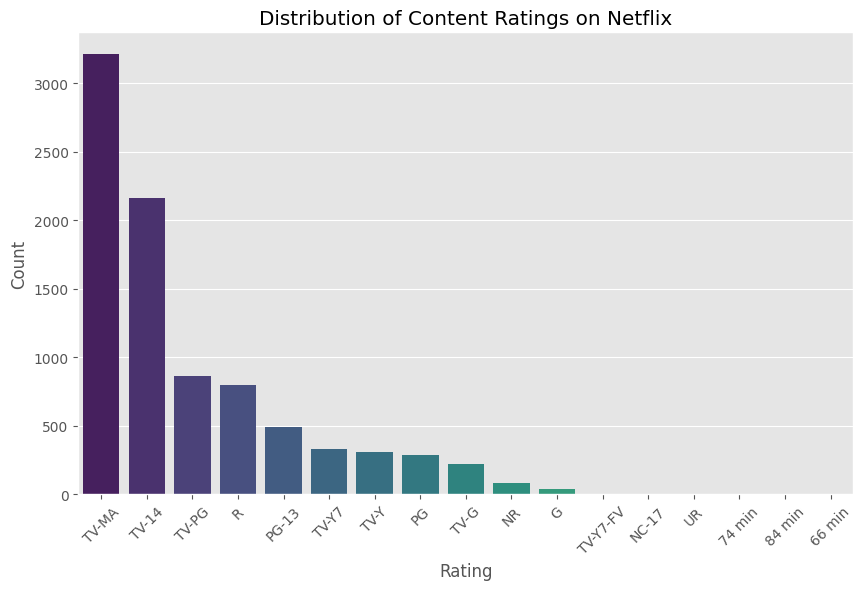

In [13]:
plt.figure(figsize=(10, 6))
sns.countplot(x='rating', data=df, order=df['rating'].value_counts().index, palette='viridis')
plt.title('Distribution of Content Ratings on Netflix')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [8]:
# Display the first 5 rows of the DataFrame
display(df.head())

# Display information about the DataFrame, including data types and non-null values
display(df.info())

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,NaN,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,NaN,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,NaN,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,NaN,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,NaN,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      8807 non-null   object        
 4   cast          8807 non-null   object        
 5   country       8807 non-null   object        
 6   date_added    8807 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   object        
 9   duration      0 non-null      float64       
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(9)
memory usage: 825.8+ KB


None

### Missing Values Analysis

It's important to identify missing values to understand the completeness of our data. We'll check the count and percentage of missing values for each column.

In [3]:
# Calculate the number of missing values for each column
missing_values = df.isnull().sum()

# Calculate the percentage of missing values for each column
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Create a DataFrame to display missing values
missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

# Filter to show only columns with missing values and sort them
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)
display(missing_info)

,Missing Count,Missing Percentage
director,2634,29.908028
country,831,9.435676
cast,825,9.367549
date_added,10,0.113546
rating,4,0.045418
duration,3,0.034064


### Data Cleaning and Feature Engineering (Re-running to ensure column creation)

Let's re-address missing values and convert data types, then extract `year_added` and `month_added`.

### Feature Engineering from `date_added` (Re-running)

Now that `date_added` is in datetime format, we can extract useful features like the year and month to analyze trends over time.

In [15]:
# Extract year and month from 'date_added'
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

print('DataFrame head with new columns:')
display(df.head())

DataFrame head with new columns:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,NaN,Documentaries,"As her father nears the end of his life, filmm...",2021,9
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,NaN,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,NaN,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,NaN,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,NaN,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9


### Exploratory Data Analysis (EDA) Continued

Now that our data is prepared, let's re-run the visualizations.

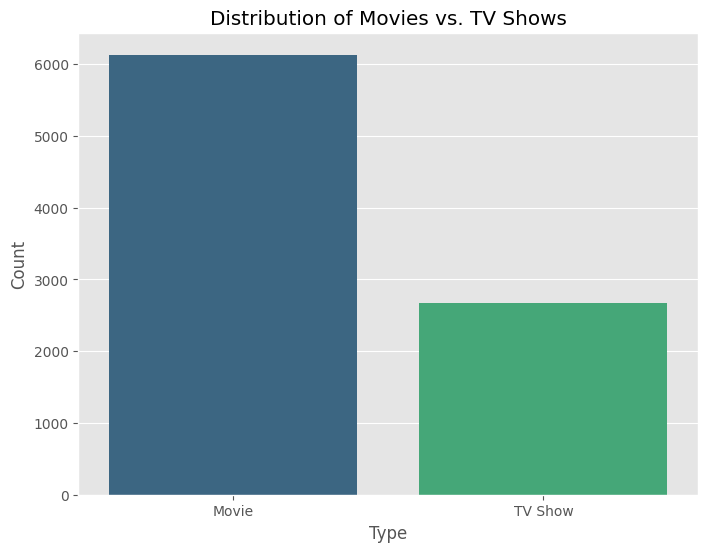

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot') # Set a nice plotting style

# Distribution of Content Types (Movies vs. TV Shows)
plt.figure(figsize=(8, 6))
sns.countplot(x='type', data=df, palette='viridis', hue='type', legend=False)
plt.title('Distribution of Movies vs. TV Shows')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

### Content Added Over Time

Let's see how the number of titles added to Netflix has changed over the years.

/tmp/ipykernel_10591/1991043376.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='year_added', data=df, order=sorted(df['year_added'].unique()), palette='plasma')


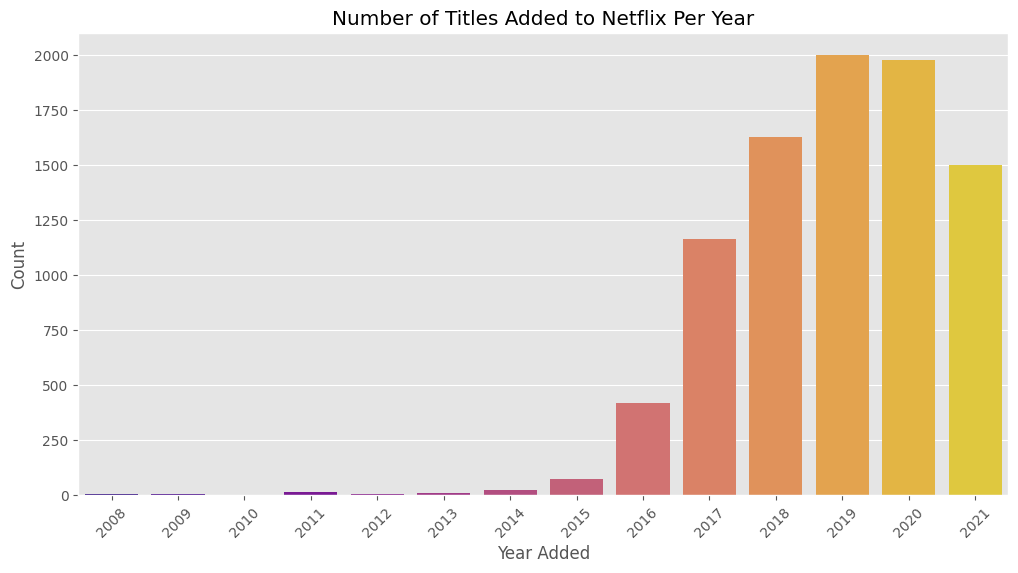

/tmp/ipykernel_10591/1991043376.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='month_added', data=df, palette='magma')


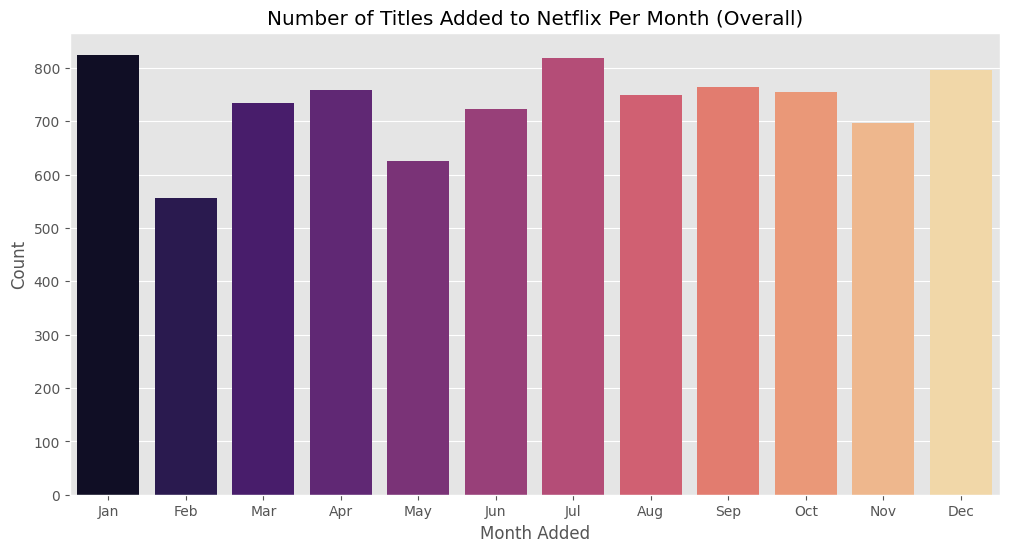

In [17]:
# Content added per year
plt.figure(figsize=(12, 6))
sns.countplot(x='year_added', data=df, order=sorted(df['year_added'].unique()), palette='plasma')
plt.title('Number of Titles Added to Netflix Per Year')
plt.xlabel('Year Added')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Content added per month (overall)
plt.figure(figsize=(12, 6))
sns.countplot(x='month_added', data=df, palette='magma')
plt.title('Number of Titles Added to Netflix Per Month (Overall)')
plt.xlabel('Month Added')
plt.ylabel('Count')
plt.xticks(ticks=range(12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

### Top Countries Producing Content

Let's identify which countries are contributing the most content to Netflix. Note that a single title can be associated with multiple countries.

/tmp/ipykernel_10591/548033.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.index, y=top_countries.values, palette='cubehelix')


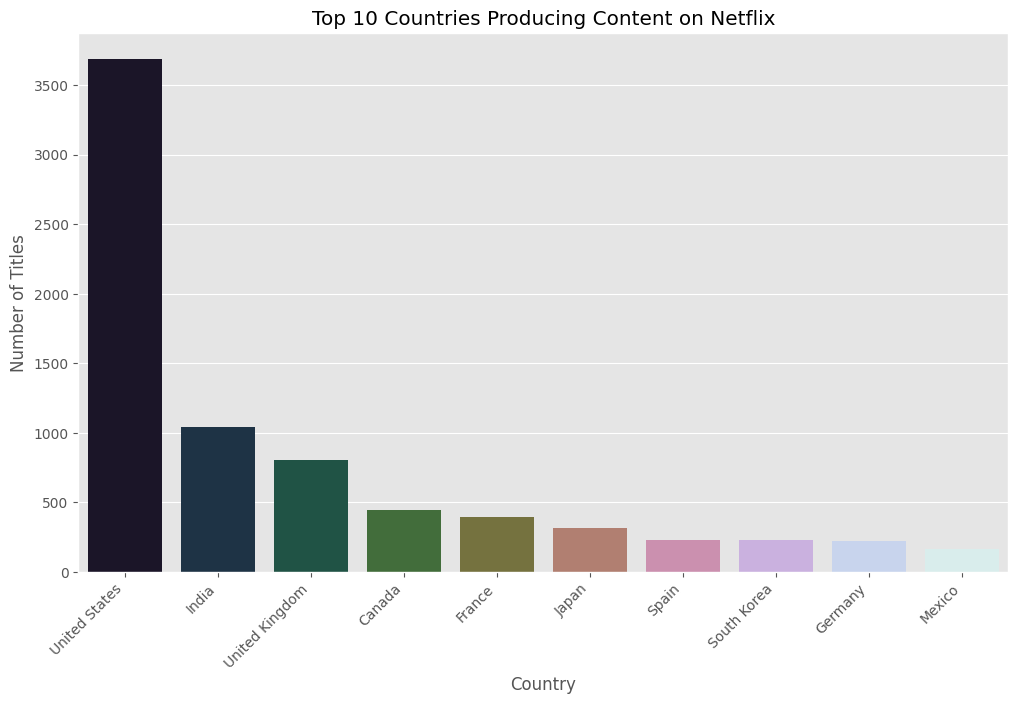

In [18]:
# Function to split and count occurrences of items in a column
def count_occurrences(df_col):
    # Drop 'Unknown' and split by comma
    split_items = df_col[df_col != 'Unknown'].str.split(', ')
    # Explode the list of lists into a series of individual items
    flat_list = [item for sublist in split_items.dropna() for item in sublist]
    return pd.Series(flat_list).value_counts()

# Top 10 Countries
top_countries = count_occurrences(df['country']).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_countries.index, y=top_countries.values, palette='cubehelix')
plt.title('Top 10 Countries Producing Content on Netflix')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.show()

### Content Ratings Distribution

Let's visualize the distribution of content ratings.

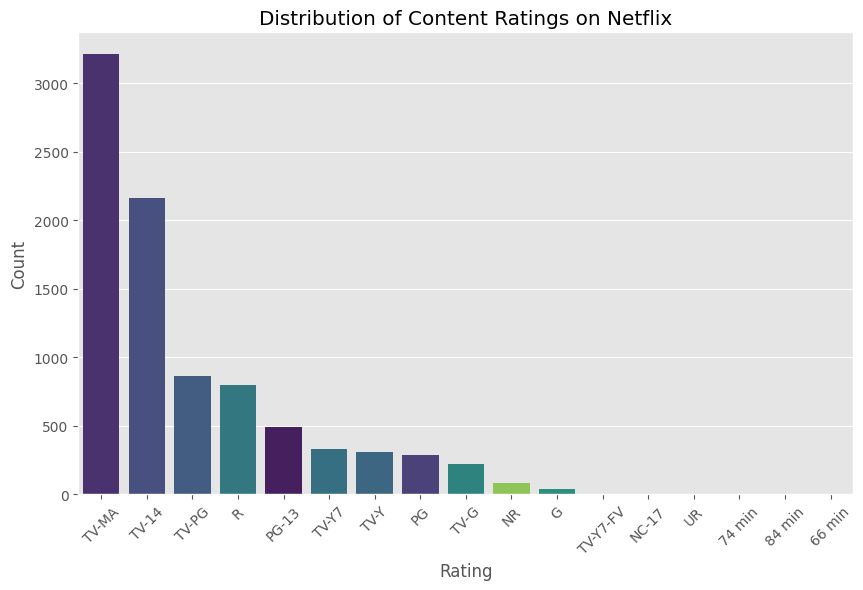

In [19]:
plt.figure(figsize=(10, 6))
sns.countplot(x='rating', data=df, order=df['rating'].value_counts().index, palette='viridis', hue='rating', legend=False)
plt.title('Distribution of Content Ratings on Netflix')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()